# Regime detection, weekly

The [daily replication](regime_detection.ipynb) took the paper on its own terms: 2,494
sessions, K-Means on 15 standardised features through a PCA, and the honest finding that
persistence beats every fitted classifier while the strategy's drawdown advantage traces
to a single event.

This notebook re-asks the same questions at **weekly** frequency. It is not a resample and
a rerun. Three things had to be decided before a single number came out, and §1 states them
because each one could have manufactured a result on its own.

The comparison to the daily run is the point, so every table that has a daily twin is shown
beside it.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
while not (ROOT / "backtest").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
HERE = ROOT / "research" / "regime_detection"
OUT = ROOT / "out" / "regime_detection"
sys.path[:0] = [str(ROOT)]

from research.regime_detection.features import FEATURES, build_features
from research.regime_detection import weekly as wk
from research.regime_detection.weekly import WEEKLY_FEATURES, build_weekly_features
from research.regime_detection import pipeline as pl
from research.regime_detection.pipeline import BULL, BEAR

pd.set_option("display.width", 170, "display.max_columns", 40)
print("repo:     ", ROOT)
WEEKLY = list(WEEKLY_FEATURES)
print("weekly features:", len(WEEKLY))

repo:      /Users/kunjshah/Downloads/pxq_stocks
weekly features: 15


In [2]:
# ---- chart styling -------------------------------------------------------
# Same validated palette the other notebooks in this repo use: categorical hues
# assigned in fixed order, never cycled, and checked for colour-vision deficiency.
SERIES = {
    "blue":    "#2a78d6",
    "orange":  "#eb6834",
    "aqua":    "#1baf7a",
    "yellow":  "#eda100",
    "violet":  "#4a3aa7",
    "red":     "#e34948",
}
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "legend.frameon": False, "figure.dpi": 110, "lines.linewidth": 2.0,
})

# Regime identity is fixed to the entity, not to rank or row order.
HUE = {BULL: SERIES["blue"], BEAR: SERIES["orange"]}
pct = FuncFormatter(lambda x, _: f"{x:.0%}")

def end_label(ax, series, text, color, dx=6):
    '''Direct label at the end of a line, so identity is never colour-alone.'''
    y = series.dropna().iloc[-1]
    ax.annotate(text, xy=(series.dropna().index[-1], y), xytext=(dx, 0),
                textcoords="offset points", color=color, fontsize=10,
                fontweight="bold", va="center")

def compare(ours, paper, index, label_ours="this replication", label_paper="paper"):
    '''Put our number next to theirs in one frame -- never one without the other.'''
    return pd.DataFrame({label_paper: paper, label_ours: ours}, index=index)

## 1 — Three decisions the frequency change forces

**Windows are calendar-matched, not literal.** The paper's `Volatility_20D` is one trading
month, so its weekly reading is **four weeks**, not twenty. Taking the numbers literally
would make `MA200` a 200-*week* average and burn 3.8 of the 10.7 years on warmup. Both
conventions live in `weekly.py` (`WINDOWS`, `LITERAL_WINDOWS`); the literal one is a
robustness check at the end, not the baseline.

**Volatility is estimated from daily returns, sampled weekly.** This is the decision that
matters most and the one most easily got wrong. A four-week window contains *four* weekly
returns, and a standard deviation from n=4 carries ~40% sampling error — it would be mostly
noise entering the clustering as if it were signal. So `Volatility_4W` is the standard
deviation of the **daily** returns inside the trailing four weeks (~20 observations,
exactly the paper's sample size), annualised by √252 and read off at the Friday close. That
is causal: at Friday's close every daily return in the window is known.

**Volume sums within the week; every other series is the Friday close.** A week's volume is
the week's total, so `Volume_Ratio` is one week's total over the trailing four-week mean.

Nothing here is shifted. The clustering is a contemporaneous description of a week, as it
was of a day (Section V.F); the one mandatory lag is in the strategy and stays visible
there.

In [3]:
panel = pd.read_parquet(ROOT / "data" / "regime_panel.parquet")
wpanel = wk.weekly_panel(panel)
frame = build_weekly_features(panel)

print(f"daily panel : {len(panel):,} sessions   {panel.index.min():%Y-%m-%d} -> {panel.index.max():%Y-%m-%d}")
print(f"weekly panel: {len(wpanel):,} weeks")
print(f"usable      : {len(frame):,} weeks after {len(wpanel) - len(frame)} warmup weeks dropped"
      f"   ({len(frame)/52:.1f} years)")
frame[WEEKLY].describe().T[["mean", "std", "min", "max"]].round(4)

daily panel : 2,693 sessions   2016-01-04 -> 2026-09-18
weekly panel: 559 weeks
usable      : 520 weeks after 39 warmup weeks dropped   (10.0 years)


,mean,std,min,max
Return,0.0027,0.0238,-0.1510,0.1221
Log_Return,0.0024,0.0240,-0.1637,0.1152
Volatility_4W,0.1486,0.0988,0.0348,0.8761
Volatility_12W,0.1553,0.0878,0.0513,0.5831
Momentum_4W,0.0109,0.0450,-0.3120,0.2491
Momentum_12W,0.0317,0.0676,-0.2895,0.3269
Distance_MA10W,0.0112,0.0357,-0.2550,0.1103
Distance_MA40W,0.0483,0.0616,-0.2462,0.1707
Drawdown,-0.0445,0.0592,-0.3205,0.0000
Volume_Ratio,1.0006,0.2270,0.4904,2.3569


### The volatility decision, measured rather than asserted

`Volatility_4W_naive` is the shortcut — the standard deviation of four weekly returns. It is
carried on the frame purely so the cost of not taking it is visible.

correlation: 0.841
                       mean     std     min     max
Volatility_4W        0.1486  0.0988  0.0348  0.8761
Volatility_4W_naive  0.1385  0.1063  0.0130  0.9219


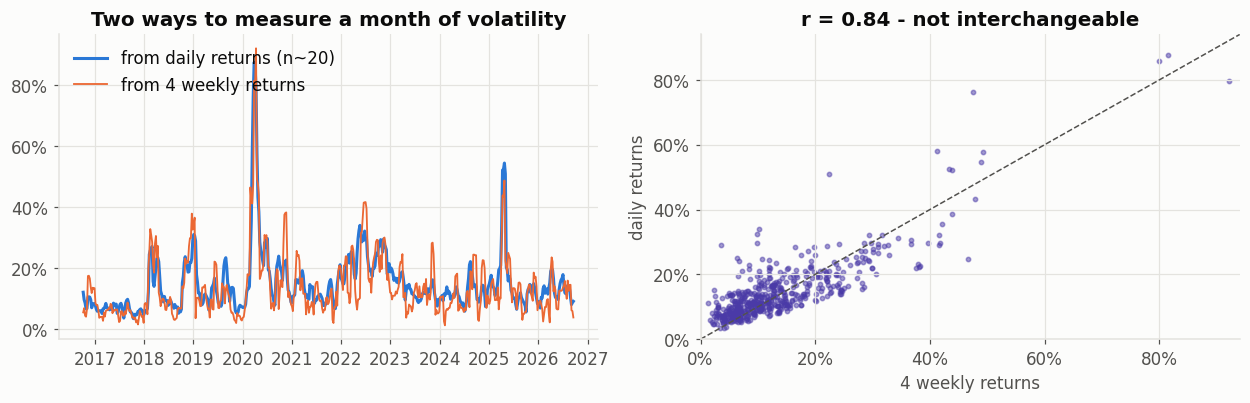

In [4]:
v = frame[["Volatility_4W", "Volatility_4W_naive"]]
print(f"correlation: {v.Volatility_4W.corr(v.Volatility_4W_naive):.3f}")
print(v.describe().T[["mean", "std", "min", "max"]].round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax = axes[0]
ax.plot(v.index, v.Volatility_4W, color=SERIES["blue"], label="from daily returns (n~20)")
ax.plot(v.index, v.Volatility_4W_naive, color=SERIES["orange"], lw=1.2,
        label="from 4 weekly returns")
ax.yaxis.set_major_formatter(pct)
ax.set_title("Two ways to measure a month of volatility")
ax.legend(loc="upper left")

ax = axes[1]
ax.scatter(v.Volatility_4W_naive, v.Volatility_4W, s=8, alpha=0.5, color=SERIES["violet"])
lim = [0, float(v.max().max()) * 1.02]
ax.plot(lim, lim, color=INK_2, lw=1.0, ls="--")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("4 weekly returns"); ax.set_ylabel("daily returns")
ax.set_title("r = 0.84 - not interchangeable")
fig.tight_layout()

A correlation of **0.84** is the whole argument. The naive estimator is not a noisier
version of the same number, it is a different number — it reaches both lower (1.3% vs 3.5%
minimum) and higher, because four observations let one week dominate. Feeding it to a
distance-based clustering would have put that noise into the regime definition.

## 2 — PCA and K: the structure survives the frequency change

Standardise on the training slice, keep components to 90% variance, cluster, and let the
training-period silhouette choose K — the paper's procedure, unchanged.

In [5]:
fit = pl.fit_regimes(frame, feature_names=WEEKLY)
print(f"components retained: {fit.n_components}   K selected: {fit.k}   "
      f"split at {fit.split_date:%Y-%m-%d}")
print(f"GMM (2 components, full covariance) agrees with K-Means on {fit.gmm_agreement:.1%} of weeks")
fit.explained_variance.head(8).round(4)

components retained: 7   K selected: 2   split at 2023-09-22
GMM (2 components, full covariance) agrees with K-Means on 79.6% of weeks


,explained_variance,cumulative
PC1,0.3952,0.3952
PC2,0.2353,0.6305
PC3,0.0778,0.7083
PC4,0.0690,0.7773
PC5,0.0588,0.8362
PC6,0.0447,0.8809
PC7,0.0372,0.9181
PC8,0.0257,0.9439


    daily  weekly
K                
2  0.4097  0.4148
3  0.3649  0.3535
4  0.3363  0.3195
5  0.3355  0.3132
6  0.2842  0.2238


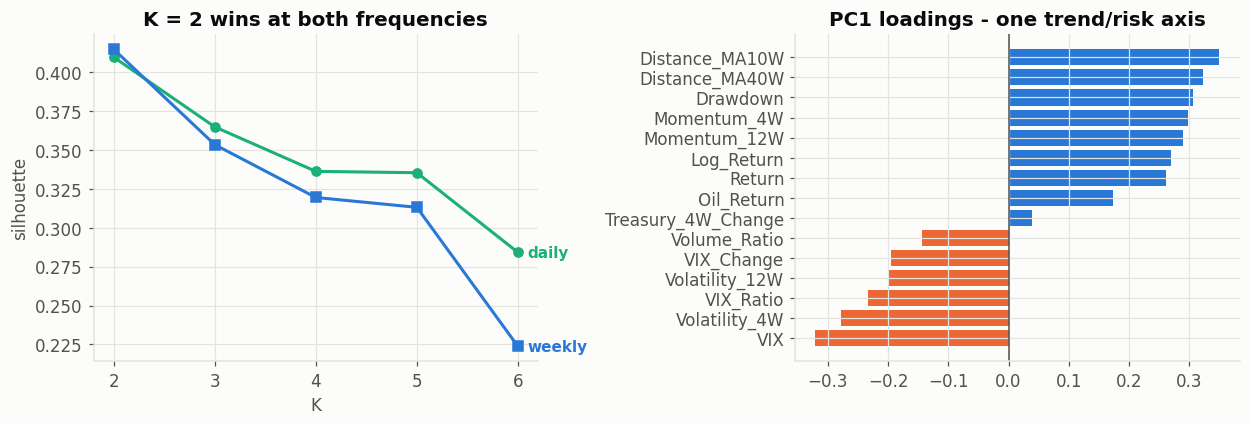

In [6]:
daily_frame = build_features(panel)
daily_fit = pl.fit_regimes(daily_frame)

sel = compare(fit.selection["silhouette"], daily_fit.selection["silhouette"],
              index=fit.selection.index, label_ours="weekly", label_paper="daily")
sel.index.name = "K"

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
ax = axes[0]
ax.plot(sel.index, sel["daily"], marker="o", color=SERIES["aqua"])
ax.plot(sel.index, sel["weekly"], marker="s", color=SERIES["blue"])
end_label(ax, sel["daily"], "daily", SERIES["aqua"])
end_label(ax, sel["weekly"], "weekly", SERIES["blue"])
ax.set_xticks(list(sel.index)); ax.set_xlabel("K"); ax.set_ylabel("silhouette")
ax.set_title("K = 2 wins at both frequencies")

ax = axes[1]
load = fit.loadings["PC1"].sort_values()
ax.barh(load.index, load.values,
        color=[SERIES["orange"] if x < 0 else SERIES["blue"] for x in load.values])
ax.axvline(0, color=INK_2, lw=1.0)
ax.set_title("PC1 loadings - one trend/risk axis")
fig.tight_layout()
print(sel.round(4).to_string())

**K = 2, decisively, and for the same reason.** Weekly silhouette at K=2 is **0.415**
against the daily run's 0.410, and the decline after K=2 is monotone in both. PC1 is the
same single trend/risk axis: momentum, distance from both moving averages and drawdown load
one way, VIX and both volatilities the other. The frequency change did not reorganise the
structure — it is the same two states seen through a coarser sampler.

## 3 — The two regimes, beside their daily twins

Labels follow Section V.F: the higher-mean-return cluster is Bull. Note that
`mean_daily_return` is a column name inherited from the daily module — at this frequency
every one of those rows is a **weekly** figure, which is why the means are ~5× larger.
Annualised volatility is on √52 here and √252 there, so *that* row is directly comparable.

In [7]:
ws = pl.regime_stats(frame, fit.labels, periods=52, momentum=wk.MOMENTUM)
ds = pl.regime_stats(daily_frame, daily_fit.labels)
side = pd.concat({"weekly": ws.T, "daily": ds.T}, axis=1)
side.loc[["observations", "share", "annualised_volatility", "mean_vix", "mean_drawdown"]].round(4)

weekly                            daily                 
regime                Bull / Low-Risk Bear / High-Risk Bull / Low-Risk Bear / High-Risk
observations                 434.0000          86.0000       2043.0000         451.0000
share                          0.8346           0.1654          0.8192           0.1808
annualised_volatility          0.1188           0.2815          0.1157           0.3253
mean_vix                      16.3259          28.9467         16.4800          28.5613
mean_drawdown                 -0.0269          -0.1337         -0.0275          -0.1369

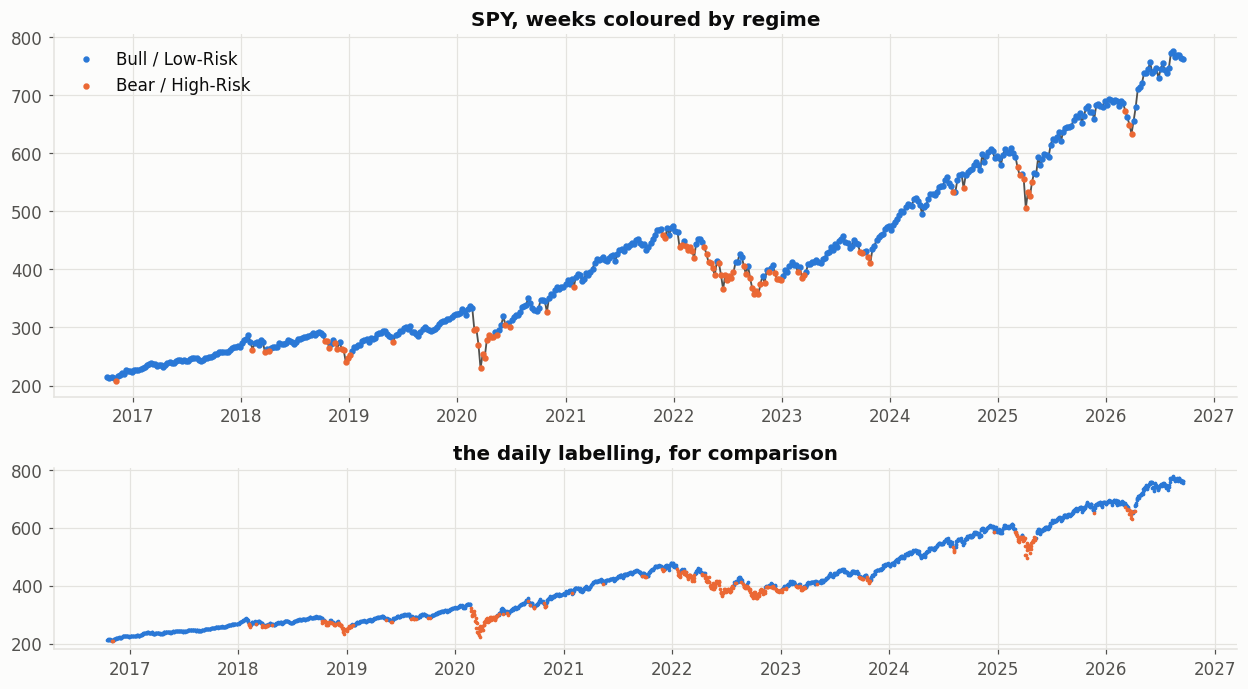

In [8]:
reg = frame.assign(regime=fit.labels)
fig, axes = plt.subplots(2, 1, figsize=(11.5, 6.4), sharex=False,
                         gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
ax.plot(reg.index, reg.close, color=INK_2, lw=1.2, zorder=3)
for name, hue in HUE.items():
    sub = reg[reg.regime == name]
    ax.scatter(sub.index, sub.close, s=10, color=hue, label=name, zorder=4)
ax.set_title("SPY, weeks coloured by regime")
ax.legend(loc="upper left")

ax = axes[1]
dreg = daily_frame.assign(regime=daily_fit.labels)
for name, hue in HUE.items():
    sub = dreg[dreg.regime == name]
    ax.scatter(sub.index, sub.close, s=2, color=hue, zorder=4)
ax.set_title("the daily labelling, for comparison")
fig.tight_layout()

The Bear weeks land where a human would put them — Q1 2016, Q4 2018, March 2020, all of
2022, and the 2025 drawdown — and the two panels mark the same episodes. Weekly Bear is
**16.5%** of the sample against daily **18.1%**, and carries **28.1%** annualised
volatility against **32.5%**. Both differences point the same way: weekly sampling averages
away the most violent individual days, so the Bear state is slightly rarer and slightly
milder, but it is the same state.

## 4 — Is the separation real?

Welch t, Mann-Whitney U and Cohen's d on the eight variables of Table 5, weekly names.

In [9]:
sig = pl.significance_tests(frame, fit.labels, variables=wk.TEST_VARIABLES)
sig.insert(0, "variable", wk.TEST_VARIABLES)
sig.round(4)

,variable,bull_mean,bear_mean,welch_t,welch_p,mannwhitney_p,cohens_d
variable,,,,,,,
Return,Return,0.0070,-0.0188,6.0146,0.0,0.0,1.1797
VIX,VIX,16.3259,28.9467,-12.6652,0.0,0.0,-2.3565
Volatility_4W,Volatility_4W,0.1245,0.2700,-8.3447,0.0,0.0,-1.7585
Volatility_12W,Volatility_12W,0.1384,0.2406,-7.7487,0.0,0.0,-1.2899
Drawdown,Drawdown,-0.0269,-0.1337,15.1903,0.0,0.0,2.4321
Momentum_4W,Momentum_4W,0.0213,-0.0419,8.5649,0.0,0.0,1.6481
Momentum_12W,Momentum_12W,0.0495,-0.0585,11.6342,0.0,0.0,1.9830
Distance_MA40W,Distance_MA40W,0.0675,-0.0487,17.1638,0.0,0.0,2.6459


Every sign matches the daily run and every effect size is large — Cohen's d from **1.18**
(Return) to **2.65** (Distance_MA40W). Nothing here depends on the frequency; two states
this far apart separate however you sample them.

## 5 — Persistence collapses, and that is the interesting part

This is where weekly genuinely differs. The daily Bear state was 79.8% sticky
day-over-day; a week is long enough for the state to change.

In [10]:
wt = pl.transition_matrix(fit.labels)
dt = pl.transition_matrix(daily_fit.labels)
print("weekly, week-over-week:"); print(wt.round(4).to_string())
print()
print("daily, day-over-day:"); print(dt.round(4).to_string())
print()
we, de = pl.episode_summary(fit.labels), pl.episode_summary(daily_fit.labels)
print("episode length, weekly (weeks):"); print(we.round(2).to_string())
print()
print("episode length, daily (sessions):"); print(de.round(2).to_string())

weekly, week-over-week:
next              Bull / Low-Risk  Bear / High-Risk
current                                            
Bull / Low-Risk            0.9215            0.0785
Bear / High-Risk           0.3953            0.6047

daily, day-over-day:
next              Bull / Low-Risk  Bear / High-Risk
current                                            
Bull / Low-Risk            0.9554            0.0446
Bear / High-Risk           0.2018            0.7982

episode length, weekly (weeks):
                  episodes   mean  median  min  max
regime                                             
Bear / High-Risk        34   2.53     2.0    1   10
Bull / Low-Risk         35  12.40     4.0    1   65

episode length, daily (sessions):
                  episodes   mean  median  min  max
regime                                             
Bear / High-Risk        91   4.96     2.0    1   66
Bull / Low-Risk         92  22.21     3.0    1  312


Bull persists at **92.2%** week-over-week (daily 95.5%) and Bear at only **60.5%** (daily
79.8%). A Bear episode runs a median of **2 weeks**, 10 at the longest. So the weekly Bear
state is close to a coin flip on whether it survives the week — which sets up the one test
the daily run could not give a fair hearing.

## 6 — Forecasting: H4 rejected again, and for a sharper reason

At daily frequency persistence was 95.5% accurate and no classifier beat it — but with a
state that sticky, "predict no change" is nearly unbeatable by construction, so the test was
weak. Weekly persistence is only 90.4%, leaving real room. The models now have their chance.

In [11]:
scores, importance = pl.forecast(frame, fit.labels, feature_names=WEEKLY)
dscores, dimportance = pl.forecast(daily_frame, daily_fit.labels)
n_test = int(round(len(frame) * 0.30))
print(f"held-out weeks: ~{n_test}")
print()
print("weekly:"); print(scores.round(4).to_string())
print()
print("daily, for comparison:"); print(dscores.round(4).to_string())

held-out weeks: ~156

weekly:
                      accuracy  precision_bull  recall_bull  f1_bull  recall_bear
model                                                                            
Persistence Baseline    0.9038          0.9500       0.9433   0.9466       0.5333
Logistic Regression     0.9103          0.9320       0.9716   0.9514       0.3333
Random Forest           0.9103          0.9262       0.9787   0.9517       0.2667
Gradient Boosting       0.8718          0.9291       0.9291   0.9291       0.3333

daily, for comparison:
                      accuracy  precision_bull  recall_bull  f1_bull  recall_bear
model                                                                            
Persistence Baseline    0.9545          0.9746       0.9746   0.9746       0.7848
Logistic Regression     0.9492          0.9606       0.9836   0.9719       0.6582
Random Forest           0.9532          0.9662       0.9821   0.9741       0.7089
Gradient Boosting       0.9452          0.97

best model      : Logistic Regression
accuracy        : 0.9103 vs persistence 0.9038   (+0.64 pp)
in held-out weeks: +1.0 weeks

recall on Bear  : 0.3333 vs persistence 0.5333   (-20.0 pp)


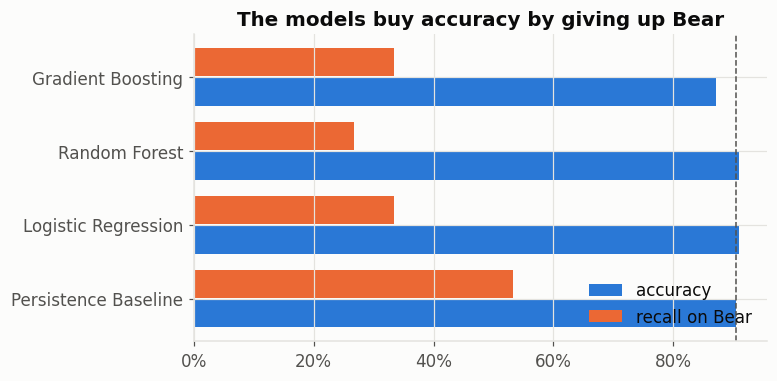

In [12]:
base = scores.loc["Persistence Baseline"]
best = scores.loc[scores.accuracy.idxmax()]
print(f"best model      : {scores.accuracy.idxmax()}")
print(f"accuracy        : {best.accuracy:.4f} vs persistence {base.accuracy:.4f}"
      f"   (+{(best.accuracy - base.accuracy) * 100:.2f} pp)")
print(f"in held-out weeks: {(best.accuracy - base.accuracy) * n_test:+.1f} weeks")
print()
print(f"recall on Bear  : {best.recall_bear:.4f} vs persistence {base.recall_bear:.4f}"
      f"   ({(best.recall_bear - base.recall_bear) * 100:+.1f} pp)")

fig, ax = plt.subplots(figsize=(7.2, 3.6))
y = np.arange(len(scores))
ax.barh(y - 0.2, scores.accuracy, height=0.38, color=SERIES["blue"], label="accuracy")
ax.barh(y + 0.2, scores.recall_bear, height=0.38, color=SERIES["orange"], label="recall on Bear")
ax.axvline(base.accuracy, color=INK_2, lw=1.0, ls="--")
ax.set_yticks(y); ax.set_yticklabels(scores.index)
ax.xaxis.set_major_formatter(pct)
ax.set_title("The models buy accuracy by giving up Bear")
ax.legend(loc="lower right")
fig.tight_layout()

**H4 is rejected here too, and the weekly version is more damning than the daily one.**

Logistic Regression and Random Forest do edge persistence on accuracy — 91.03% against
90.38% — **+0.64 pp**. On ~156 held-out weeks that is **one extra correct week**, which is noise. But look
at how they earn it: persistence catches **53.3%** of Bear weeks, the best model catches
**33.3%** and the Random Forest only 26.7%. The classifiers gain a hair of headline accuracy
by predicting Bull more often — they are *worse at the only prediction anyone would act on*.

At daily frequency you could argue persistence won because the state barely moved. Weekly
removes that excuse: persistence is beatable in principle here, and the models still do not
beat it in any way that matters.

top 6 weekly:
Distance_MA40W    0.1224
Momentum_12W      0.1109
Distance_MA10W    0.1035
Drawdown          0.0844
VIX               0.0785
Volatility_4W     0.0708

top 6 daily :
Distance_MA200    0.1623
Distance_MA50     0.1413
Momentum_60D      0.1308
Drawdown          0.1116
Volatility_20D    0.0915
VIX               0.0716


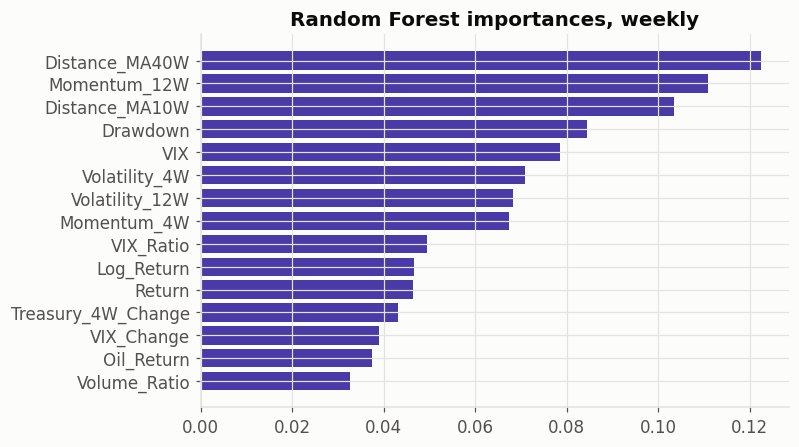

In [13]:
imp = importance.sort_values()
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.barh(imp.index, imp.values, color=SERIES["violet"])
ax.set_title("Random Forest importances, weekly")
fig.tight_layout()
print("top 6 weekly:"); print(importance.sort_values(ascending=False).head(6).round(4).to_string())
print()
print("top 6 daily :"); print(dimportance.sort_values(ascending=False).head(6).round(4).to_string())

The same family of variables leads at both frequencies — distance from the long moving
average, the slower momentum, drawdown, VIX. Medium-to-low-frequency state descriptors,
not the noisy one-period terms.

## 7 — The strategy: the one place weekly is genuinely better

100% invested the week after a Bull label, flat the week after a Bear label, 10bps on every
unit of position change. The lag is the point: this week's exposure is set by *last* week's
label.

In [14]:
res = pl.tactical_strategy(frame, fit.labels, cost_bps=10.0)
dres = pl.tactical_strategy(daily_frame, daily_fit.labels, cost_bps=10.0)

perf = pd.DataFrame({
    "weekly strategy": pl.performance(res.strategy_return, periods=52),
    "weekly buy & hold": pl.performance(res.benchmark_return, periods=52),
    "daily strategy": pl.performance(dres.strategy_return),
    "daily buy & hold": pl.performance(dres.benchmark_return),
})
print(perf.round(4).to_string())
print()
print(f"weekly turnover: {res.turnover.sum():.0f} switches over {len(res)} weeks"
      f"   ({res.turnover.sum() / (len(res) / 52):.1f}/yr)")
print(f"daily turnover : {dres.turnover.sum():.0f} switches over {len(dres)} sessions"
      f"   ({dres.turnover.sum() / (len(dres) / 252):.1f}/yr)")

                       weekly strategy  weekly buy & hold  daily strategy  daily buy & hold
total_return                    0.9752             2.5206          0.9922            2.5750
cagr                            0.0704             0.1341          0.0721            0.1374
annualised_volatility           0.1188             0.1718          0.1151            0.1778
sharpe                          0.6330             0.8200          0.6629            0.8132
max_drawdown                   -0.2728            -0.3205         -0.2572           -0.3418
calmar                          0.2582             0.4185          0.2805            0.4019
pct_positive_days               0.4808             0.5769          0.4527            0.5489

weekly turnover: 69 switches over 520 weeks   (6.9/yr)
daily turnover : 183 switches over 2494 sessions   (18.5/yr)


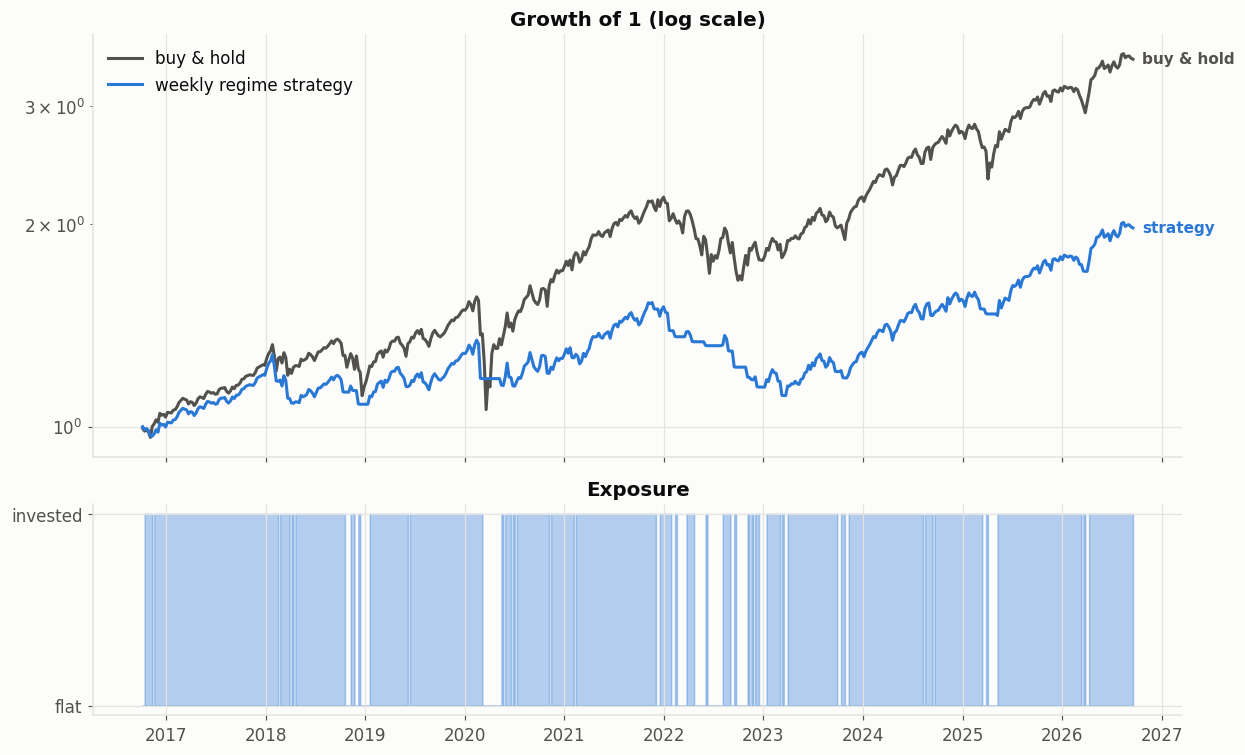

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.0), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
ax.plot(res.index, res.benchmark_equity, color=INK_2, label="buy & hold")
ax.plot(res.index, res.strategy_equity, color=SERIES["blue"], label="weekly regime strategy")
end_label(ax, res.benchmark_equity, "buy & hold", INK_2)
end_label(ax, res.strategy_equity, "strategy", SERIES["blue"])
ax.set_yscale("log"); ax.set_title("Growth of 1 (log scale)")
ax.legend(loc="upper left")

ax = axes[1]
ax.fill_between(res.index, res.exposure, color=SERIES["blue"], alpha=0.35, step="post")
ax.set_ylim(-0.05, 1.05); ax.set_yticks([0, 1]); ax.set_yticklabels(["flat", "invested"])
ax.set_title("Exposure")
fig.tight_layout()

               max    mean  median  pct of weeks in >5% dd
buy & hold -0.3205 -0.0444 -0.0168                  0.3135
strategy   -0.2728 -0.0744 -0.0582                  0.5346


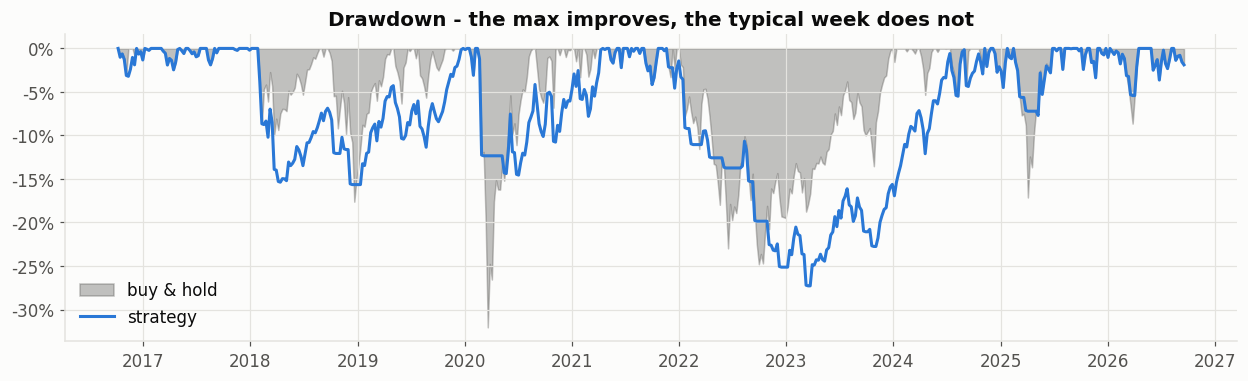

In [16]:
dd = pd.DataFrame({
    "buy & hold": res.benchmark_equity / res.benchmark_equity.cummax() - 1.0,
    "strategy": res.strategy_equity / res.strategy_equity.cummax() - 1.0,
})
summary = pd.DataFrame({
    "max": dd.min(), "mean": dd.mean(), "median": dd.median(),
    "pct of weeks in >5% dd": (dd < -0.05).mean(),
})
print(summary.round(4).to_string())

fig, ax = plt.subplots(figsize=(11.5, 3.6))
ax.fill_between(dd.index, dd["buy & hold"], color=INK_2, alpha=0.35, label="buy & hold")
ax.plot(dd.index, dd["strategy"], color=SERIES["blue"], label="strategy")
ax.yaxis.set_major_formatter(pct)
ax.set_title("Drawdown - the max improves, the typical week does not")
ax.legend(loc="lower left")
fig.tight_layout()

**The daily replication's central caveat reproduces exactly.** Max drawdown improves —
−27.3% against buy-and-hold's −32.1% — and that is the number a paper reports. But *mean*
drawdown is **−7.4%** against buy-and-hold's −4.4% and the median is −5.8% against −1.7%:
the strategy spends far more of its life underwater, it simply avoids the single worst
hole. Sharpe is lower (0.63 vs 0.82) and so is CAGR (7.0% vs 13.4%). Being flat for 16% of
the sample costs more than the crash protection returns.

**What weekly does buy is turnover.** 6.9 switches a year against the daily version's 18.5
— a 63% reduction. At 10bps that is a small saving, but it is the difference between a rule
a person can actually follow and one that asks for a decision every session. This is the
honest case for the weekly build: not better risk-adjusted returns, but the same regime
structure at a third of the trading.

## 8 — Robustness: the literal windows

`LITERAL_WINDOWS` reads the paper's numbers as weeks — a 200-week moving average. It costs
160 extra warmup weeks. If the regime structure only exists under the calendar-matched
convention, that is worth knowing.

In [17]:
lit = build_weekly_features(panel, windows=wk.LITERAL_WINDOWS)

# On its own terms first -- let the silhouette choose K as it did everywhere else.
lit_free = pl.fit_regimes(lit, feature_names=WEEKLY)
print(f"literal windows: {len(lit)} weeks usable, {len(frame) - len(lit)} fewer")
print(f"K chosen freely : {lit_free.k}   silhouette at that K "
      f"{lit_free.selection.silhouette[lit_free.k]:.4f}")
print(lit_free.selection[["silhouette"]].round(4).to_string())
print()

# Then forced to K=2, which is the only way the labelling is comparable to the
# baseline's. Comparing a K=3 solution against a K=2 one would report 0% agreement
# as an artefact of the label names, not a disagreement about the tape.
lit_fit = pl.fit_regimes(lit, feature_names=WEEKLY, k=2)
print(f"forced to K=2   : Bear share {(lit_fit.labels == BEAR).mean():.4f}   "
      f"Bear ann vol {lit.Return[lit_fit.labels == BEAR].std() * np.sqrt(52):.4f}")
overlap = fit.labels.reindex(lit_fit.labels.index)
print(f"agreement with the calendar-matched labelling, on the "
      f"{overlap.notna().sum()} shared weeks: {(overlap == lit_fit.labels).mean():.1%}")

literal windows: 360 weeks usable, 160 fewer
K chosen freely : 3   silhouette at that K 0.3213
   silhouette
K            
2      0.3144
3      0.3213
4      0.3133
5      0.2776
6      0.2695



forced to K=2   : Bear share 0.2861   Bear ann vol 0.2851
agreement with the calendar-matched labelling, on the 360 shared weeks: 85.6%


**The literal convention does not reproduce the structure.** Left to choose, it picks
**K = 3** (silhouette 0.321, with K=2 at 0.314) — both far below the calendar-matched
0.415, so the clean two-state separation is gone.

Forced to K=2 it agrees with the calendar-matched labelling on **85.6%** of the 360 shared
weeks, so it is not finding a different tape. But it calls **28.6%** of weeks Bear against
the baseline's 16.5% — nearly double — at the same Bear volatility (28.5%). A four-year
moving average is so slow that the price sits below it for long stretches of ordinary
market, which inflates the Bear state with weeks that are not stressed.

This is the expected direction and worth stating plainly: a 200-*week* moving average is not
a regime descriptor, it is a secular trend line. The calendar-matched reading is the
defensible one, and §1 committed to it before any of these numbers existed.

## 9 — Daily against weekly, in one table

In [18]:
def row(d, w):
    return pd.Series({"daily": d, "weekly": w})

comparison = pd.DataFrame({
    "observations": row(len(daily_frame), len(frame)),
    "silhouette at K=2": row(daily_fit.selection.silhouette[2], fit.selection.silhouette[2]),
    "PCs to 90% variance": row(daily_fit.n_components, fit.n_components),
    "GMM agreement": row(daily_fit.gmm_agreement, fit.gmm_agreement),
    "Bear share": row((daily_fit.labels == BEAR).mean(), (fit.labels == BEAR).mean()),
    "Bear annualised vol": row(daily_frame.Return[daily_fit.labels == BEAR].std() * np.sqrt(252),
                               frame.Return[fit.labels == BEAR].std() * np.sqrt(52)),
    "Bull persistence": row(dt.iloc[0, 0], wt.iloc[0, 0]),
    "Bear persistence": row(dt.iloc[1, 1], wt.iloc[1, 1]),
    "persistence accuracy": row(dscores.loc["Persistence Baseline", "accuracy"],
                                scores.loc["Persistence Baseline", "accuracy"]),
    "best model accuracy": row(dscores.accuracy.max(), scores.accuracy.max()),
    "persistence Bear recall": row(dscores.loc["Persistence Baseline", "recall_bear"],
                                   scores.loc["Persistence Baseline", "recall_bear"]),
    "best model Bear recall": row(dscores.loc[dscores.accuracy.idxmax(), "recall_bear"],
                                  scores.loc[scores.accuracy.idxmax(), "recall_bear"]),
    "switches per year": row(dres.turnover.sum() / (len(dres) / 252),
                             res.turnover.sum() / (len(res) / 52)),
    "strategy Sharpe": row(pl.performance(dres.strategy_return)["sharpe"],
                           pl.performance(res.strategy_return, periods=52)["sharpe"]),
    "buy & hold Sharpe": row(pl.performance(dres.benchmark_return)["sharpe"],
                             pl.performance(res.benchmark_return, periods=52)["sharpe"]),
    "strategy max drawdown": row(pl.performance(dres.strategy_return)["max_drawdown"],
                                 pl.performance(res.strategy_return, periods=52)["max_drawdown"]),
}).T
comparison.round(4)

,daily,weekly
observations,2494.0000,520.0000
silhouette at K=2,0.4097,0.4148
PCs to 90% variance,7.0000,7.0000
GMM agreement,0.8456,0.7962
Bear share,0.1808,0.1654
Bear annualised vol,0.3253,0.2815
Bull persistence,0.9554,0.9215
Bear persistence,0.7982,0.6047
persistence accuracy,0.9545,0.9038
best model accuracy,0.9545,0.9103


## What the weekly build says

**The regime structure is frequency-robust.** K=2 at a silhouette of 0.415 against the
daily 0.410, seven principal components at both, the same PC1 trend/risk axis, the same
ordering of Random Forest importances, Bear at 16.5% of weeks against 18.1% of days, and
every Table 5 separation large and correctly signed. Whatever the clustering is finding, it
is not an artefact of daily sampling. The GMM cross-check agrees with K-Means on 79.6% of
weeks — lower than the daily 84.6%, which is the expected cost of a fifth as many
observations.

**The forecasting verdict gets stronger, not weaker.** The daily rejection of H4 had a
loophole: with Bear 79.8% sticky, persistence is hard to beat for reasons that have nothing
to do with the features. Weekly closes the loophole — persistence is only 90.4% accurate and
Bear survives the week barely 60% of the time — and the classifiers still fail. They clear
persistence on accuracy by one week in 156 while cutting Bear recall from 53.3% to 33.3%.
The features describe a regime; they do not predict its transition, at either frequency.

**The strategy's drawdown claim fails the same way it failed daily.** Better max drawdown,
worse mean and median drawdown, worse Sharpe, worse CAGR. That this reproduces at a
different frequency on a different number of observations makes it a property of the
strategy rather than of one sample.

**What is actually new: 6.9 position switches a year instead of 18.5.** The weekly build
gets the same regime identification for a third of the trading. That is the reason to
prefer it — not performance, which is marginally worse, but tractability.

### Limits

- **520 weeks is not 2,494 sessions.** The held-out slice is ~156 weeks, so the forecasting
  table's differences are a handful of weeks either way. The accuracy column deserves less
  weight than the Bear-recall column, which is large enough to read.
- **The labels are still ex-post.** Bull/Bear naming uses each cluster's full-sample mean
  return (Section V.F) and the train/test split is one chronological block, so the strategy
  inherits the look-ahead the paper acknowledges and does not remove. This is unchanged from
  the daily run and is not fixed by going weekly.
- **W-FRI is a choice.** A Wednesday-ending week would produce a different labelling of the
  same tape; nothing here tests how much.
- **Volatility is the one feature measured at a different frequency from its own bar.** It
  is the right call for precision, but it does mean the feature vector is not purely weekly.